In [12]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

In [21]:
cart = pd.read_csv('cart_active_users.csv')

C:\Users\Yuka\AppData\Local\Temp\ipykernel_3940\2804111206.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


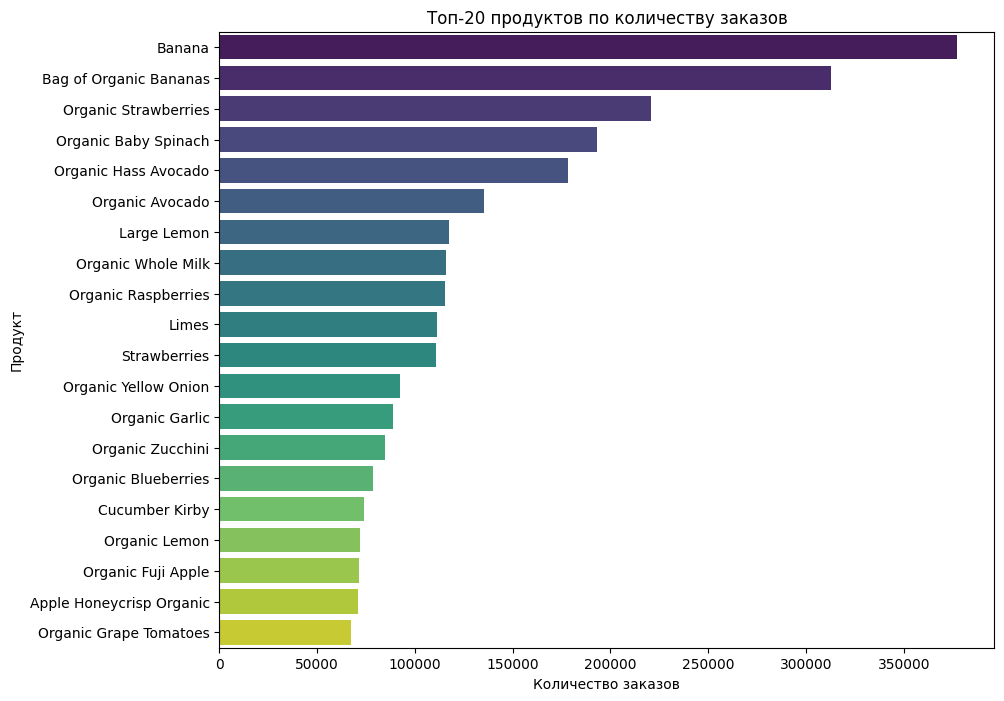

C:\Users\Yuka\AppData\Local\Temp\ipykernel_3940\2804111206.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_departments.values, y=top_departments.index, palette="magma")


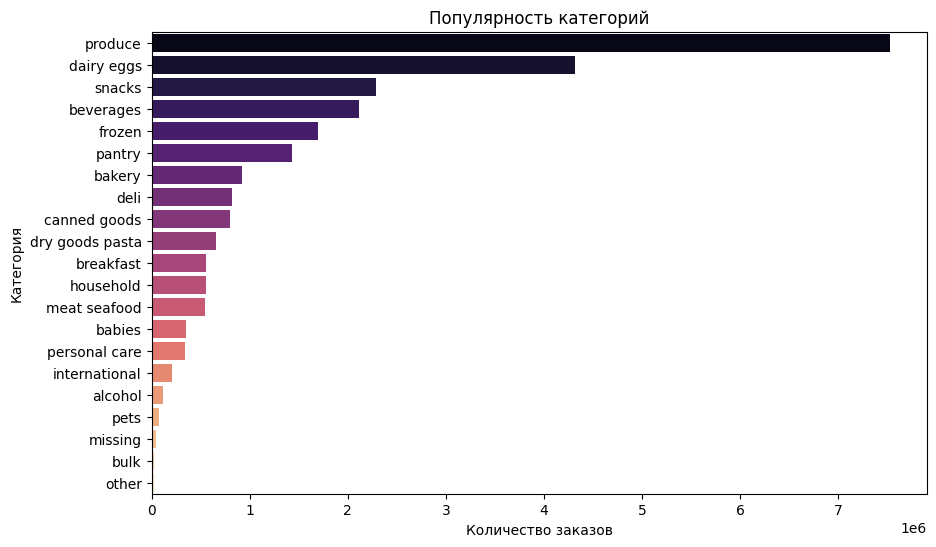

C:\Users\Yuka\AppData\Local\Temp\ipykernel_3940\2804111206.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_aisles.values, y=top_aisles.index, palette="coolwarm")


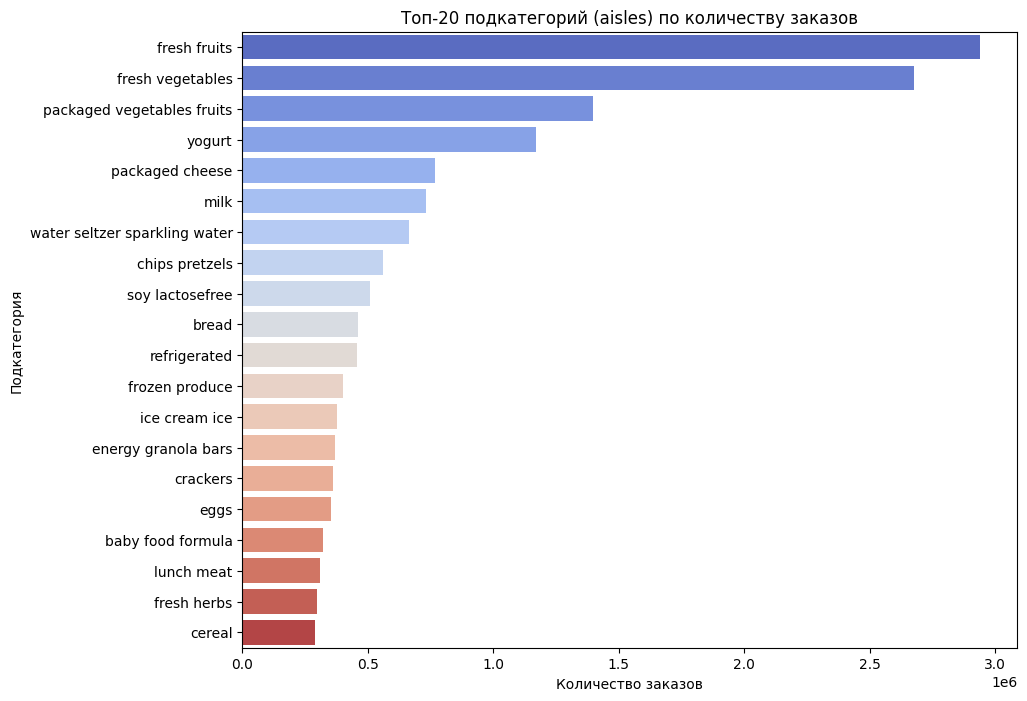

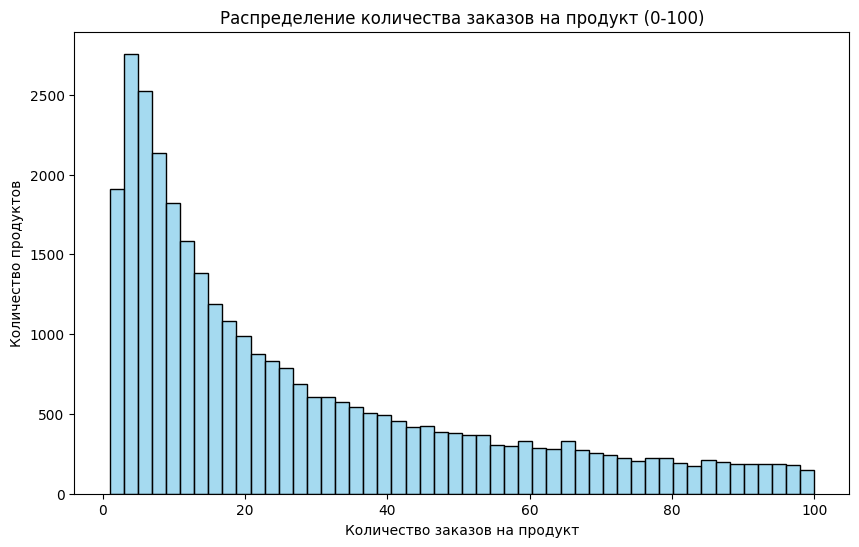

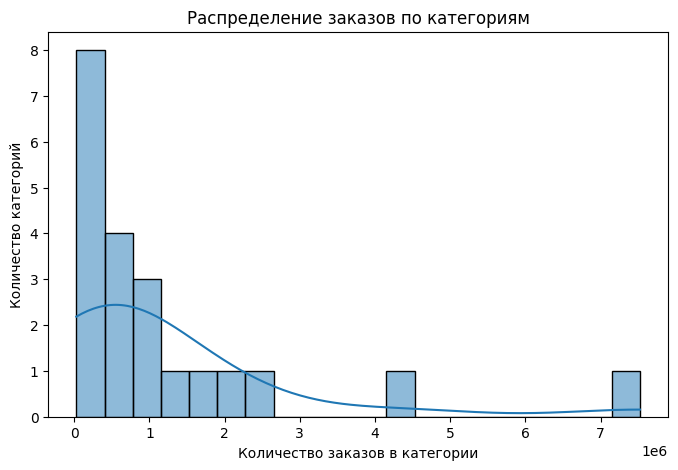

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Топ продуктов ---
top_products = cart['product_name'].value_counts().head(20)  # топ-20
plt.figure(figsize=(10,8))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Топ-20 продуктов по количеству заказов")
plt.xlabel("Количество заказов")
plt.ylabel("Продукт")
plt.show()

# --- Топ категорий (departments) ---
top_departments = cart['department'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=top_departments.values, y=top_departments.index, palette="magma")
plt.title("Популярность категорий")
plt.xlabel("Количество заказов")
plt.ylabel("Категория")
plt.show()

# --- Топ подкатегорий (aisles) ---
top_aisles = cart['aisle'].value_counts().head(20)  # топ-20
plt.figure(figsize=(10,8))
sns.barplot(x=top_aisles.values, y=top_aisles.index, palette="coolwarm")
plt.title("Топ-20 подкатегорий (aisles) по количеству заказов")
plt.xlabel("Количество заказов")
plt.ylabel("Подкатегория")
plt.show()

product_order_counts = cart['product_id'].value_counts()

plt.figure(figsize=(10,6))
sns.histplot(product_order_counts[product_order_counts <= 100], bins=50, kde=False, color='skyblue')
plt.title("Распределение количества заказов на продукт (0-100)")
plt.xlabel("Количество заказов на продукт")
plt.ylabel("Количество продуктов")
plt.show()

# --- Распределение количества заказов на категорию ---
plt.figure(figsize=(8,5))
sns.histplot(cart.groupby('department')['order_id'].count(), bins=20, kde=True)
plt.title("Распределение заказов по категориям")
plt.xlabel("Количество заказов в категории")
plt.ylabel("Количество категорий")
plt.show()


1️⃣ Активность пользователя

total_orders — общее количество заказов пользователя
Показывает, насколько активен клиент.

avg_days_between_orders — среднее количество дней между заказами
Регулярность покупок: частые vs редкие клиенты.

max_days_between_orders — максимальный промежуток между заказами
Выявляет возможные «забывчивые» клиенты и зоны риска оттока.

last_order_recency — дни с последнего заказа
Прямой индикатор риска оттока.

order_frequency — среднее количество заказов в день активности (total_orders / active_days_span)
Наглядный показатель регулярности активности клиента.

active_days_count — количество дней, когда пользователь совершал хотя бы один заказ
Позволяет увидеть, как распределены покупки во времени.

2️⃣ Размер и лояльность заказов

avg_items_per_order — среднее количество товаров в заказе 
Показывает, «малые» или «крупные» покупки делает клиент.

total_items — общее количество купленных товаров 
Суммарный размер всех заказов.

reorder_ratio — доля повторных покупок
Показывает лояльность к продуктам.

max_items_per_order — максимальное количество товаров в одном заказе
Выделяет крупные разовые покупки.

min_items_per_order — минимальное количество товаров в заказе
Выявляет «малые» покупки.

3️⃣ Разнообразие покупок

unique_products — число уникальных продуктов (product_id.nunique())
Разнообразие интересов пользователя.

unique_departments — число категорий (department_id.nunique())
Показывает, в скольких категориях делает покупки клиент.

unique_aisles — число подкатегорий/проходов (aisle_id.nunique())
Детальное разнообразие покупок.

top_department_ratio — доля заказов в самой частой категории
Смотрим, сосредоточен ли клиент на одной категории.

top_aisle_ratio — доля заказов в самой частой подкатегории
Смотрим, на какой подкатегории пользователь концентрируется.

reorder_product_variety — число уникальных продуктов, которые были повторно куплены
Показывает лояльность к конкретным продуктам и разнообразие повторных покупок.

4️⃣ Временные паттерны

most_active_dow — день недели с наибольшей активностью (order_dow.mode())
Помогает таргетировать предложения в определённые дни.

most_active_hour — час дня с наибольшей активностью (order_hour_of_day.mode())
Можно планировать персональные уведомления и акции.

dow_entropy — разнообразие дней недели, в которые делает заказы (энтропия распределения по order_dow)
Высокая энтропия → покупки разбросаны по разным дням, низкая → прогнозируемое поведение.

hour_entropy — разнообразие часов дня (энтропия по order_hour_of_day)
Смотрим предсказуемость активности по времени.

avg_order_hour — средний час заказов
Показывает привычное время покупок.

avg_order_dow — средний день недели
Для кластеризации по времени.

orders_weekend_ratio — доля заказов в выходные дни
Показывает, предпочитает ли пользователь делать покупки в выходные.

orders_morning_ratio — доля заказов в утренние часы (6–12)
Выявляет «ранних» покупателей.

orders_evening_ratio — доля заказов в вечерние часы (18–23)
Выявляет «вечерних» покупателей.

In [28]:
user_group = cart.groupby('user_id')

In [29]:
features = pd.DataFrame()
features['total_orders'] = user_group['order_number'].max()
features['avg_days_between_orders'] = user_group['days_since_prior_order'].mean()
features['max_days_between_orders'] = user_group['days_since_prior_order'].max()

features['last_order_recency'] = user_group['days_since_prior_order'].last()

user_first_last = cart.groupby('user_id')['order_number'].agg(['min','max'])
features['active_days_count'] = user_group['order_number'].nunique()

features['order_frequency'] = features['total_orders'] / features['active_days_count']

In [30]:
features['avg_items_per_order'] = user_group['add_to_cart_order'].mean()
features['total_items'] = user_group['add_to_cart_order'].sum()
features['reorder_ratio'] = user_group['reordered'].mean()
features['max_items_per_order'] = user_group['add_to_cart_order'].max()
features['min_items_per_order'] = user_group['add_to_cart_order'].min()

In [31]:
features['unique_products'] = user_group['product_id'].nunique()
features['unique_departments'] = user_group['department_id'].nunique()
features['unique_aisles'] = user_group['aisle_id'].nunique()

top_department = cart.groupby(['user_id','department_id']).size().reset_index(name='count')
top_dep_ratio = top_department.groupby('user_id')['count'].apply(lambda x: x.max()/x.sum())
features['top_department_ratio'] = top_dep_ratio

top_aisle = cart.groupby(['user_id','aisle_id']).size().reset_index(name='count')
top_aisle_ratio = top_aisle.groupby('user_id')['count'].apply(lambda x: x.max()/x.sum())
features['top_aisle_ratio'] = top_aisle_ratio

reordered_products = cart[cart['reordered']==1].groupby('user_id')['product_id'].nunique()
features['reorder_product_variety'] = reordered_products
features['reorder_product_variety'] = features['reorder_product_variety'].fillna(0)

In [32]:
features['most_active_dow'] = user_group['order_dow'].agg(lambda x: x.mode()[0])
features['most_active_hour'] = user_group['order_hour_of_day'].agg(lambda x: x.mode()[0])

def calc_entropy(series):
    counts = series.value_counts()
    return entropy(counts)

features['dow_entropy'] = user_group['order_dow'].agg(calc_entropy)
features['hour_entropy'] = user_group['order_hour_of_day'].agg(calc_entropy)

features['avg_order_hour'] = user_group['order_hour_of_day'].mean()
features['avg_order_dow'] = user_group['order_dow'].mean()

# суббота=6, воскресенье=0
features['orders_weekend_ratio'] = user_group['order_dow'].apply(lambda x: ((x==0) | (x==6)).mean())

features['orders_morning_ratio'] = user_group['order_hour_of_day'].apply(lambda x: x.between(6,12).mean())
features['orders_evening_ratio'] = user_group['order_hour_of_day'].apply(lambda x: x.between(18,23).mean())

In [33]:
features.reset_index(inplace=True)
features.to_csv('user_features.csv', index=False)

In [20]:
features.head()

,user_id,total_orders,avg_days_between_orders,max_days_between_orders,last_order_recency,active_days_count,order_frequency,avg_items_per_order,total_items,reorder_ratio,...,reorder_product_variety,most_active_dow,most_active_hour,dow_entropy,hour_entropy,avg_order_hour,avg_order_dow,orders_weekend_ratio,orders_morning_ratio,orders_evening_ratio
0,2,14,14.902564,30.0,13.0,14,1.0,8.553846,1668,0.476923,...,37,2,9,1.258232,1.453855,10.441026,2.005128,0.030769,0.917949,0.000000
1,3,12,10.181818,21.0,15.0,12,1.0,4.443182,391,0.625000,...,19,0,16,1.153915,1.717522,16.352273,1.011364,0.000000,0.000000,0.215909
2,7,20,12.757282,30.0,7.0,20,1.0,7.252427,1494,0.669903,...,40,0,9,1.604806,2.228010,13.631068,1.728155,0.140777,0.422330,0.315534
3,13,12,6.925926,13.0,6.0,12,1.0,4.148148,336,0.641975,...,13,6,13,0.879130,2.140186,15.135802,3.098765,0.506173,0.296296,0.370370
4,14,13,23.985714,30.0,7.0,13,1.0,11.080952,2327,0.323810,...,30,5,8,1.339644,1.459785,8.952381,4.076190,0.638095,0.800000,0.066667


In [34]:
# 1️⃣ Любимая категория (department)
dept_counts = cart.groupby(['user_id', 'department'])['order_id'].count().reset_index(name='count')
favorite_dept = dept_counts.loc[dept_counts.groupby('user_id')['count'].idxmax()]
favorite_dept = favorite_dept[['user_id','department','count']]
favorite_dept.rename(columns={'department':'favorite_department', 'count':'favorite_department_count'}, inplace=True)

# Доля заказов в любимой категории
user_total_orders = cart.groupby('user_id')['order_id'].count().reset_index(name='total_orders_count')
favorite_dept = favorite_dept.merge(user_total_orders, on='user_id')
favorite_dept['favorite_department_ratio'] = favorite_dept['favorite_department_count'] / favorite_dept['total_orders_count']

# 2️⃣ Любимая подкатегория (aisle)
aisle_counts = cart.groupby(['user_id', 'aisle'])['order_id'].count().reset_index(name='count')
favorite_aisle = aisle_counts.loc[aisle_counts.groupby('user_id')['count'].idxmax()]
favorite_aisle = favorite_aisle[['user_id','aisle','count']]
favorite_aisle.rename(columns={'aisle':'favorite_aisle', 'count':'favorite_aisle_count'}, inplace=True)
favorite_aisle = favorite_aisle.merge(user_total_orders, on='user_id')
favorite_aisle['favorite_aisle_ratio'] = favorite_aisle['favorite_aisle_count'] / favorite_aisle['total_orders_count']

# 3️⃣ Объединяем с исходными фичами
features = features.merge(favorite_dept[['user_id','favorite_department','favorite_department_ratio']], on='user_id', how='left')
features = features.merge(favorite_aisle[['user_id','favorite_aisle','favorite_aisle_ratio']], on='user_id', how='left')

# 4️⃣ Опционально: топ-5 продуктов (список) для каждого пользователя
top_products = cart.groupby(['user_id','product_name'])['order_id'].count().reset_index()
top_products = top_products.sort_values(['user_id','order_id'], ascending=[True,False])
top_n = 5
top_products_list = top_products.groupby('user_id')['product_name'].apply(lambda x: list(x[:top_n])).reset_index()
top_products_list.rename(columns={'product_name':'top_5_products'}, inplace=True)

# Объединяем
features = features.merge(top_products_list, on='user_id', how='left')

# 5️⃣ Сохраняем итоговый датасет
features.to_csv('user_features_final.csv', index=False)
print("Итоговый датасет с фичами и категориальными признаками сохранён как 'user_features_final.csv'")



Итоговый датасет с фичами и категориальными признаками сохранён как 'user_features_final.csv'


In [35]:
features.head()

,user_id,total_orders,avg_days_between_orders,max_days_between_orders,last_order_recency,active_days_count,order_frequency,avg_items_per_order,total_items,reorder_ratio,...,avg_order_hour,avg_order_dow,orders_weekend_ratio,orders_morning_ratio,orders_evening_ratio,favorite_department,favorite_department_ratio,favorite_aisle,favorite_aisle_ratio,top_5_products
0,2,14,14.902564,30.0,13.0,14,1.0,8.553846,1668,0.476923,...,10.441026,2.005128,0.000000,0.917949,0.000000,dairy eggs,0.246154,yogurt,0.215385,"[Chipotle Beef & Pork Realstick, Organic Hass ..."
1,3,12,10.181818,21.0,15.0,12,1.0,4.443182,391,0.625000,...,16.352273,1.011364,0.522727,0.000000,0.215909,produce,0.431818,fresh fruits,0.215909,"[Vanilla Unsweetened Almond Milk, Organic Avoc..."
2,7,20,12.757282,30.0,7.0,20,1.0,7.252427,1494,0.669903,...,13.631068,1.728155,0.427184,0.422330,0.315534,produce,0.276699,refrigerated,0.131068,"[Lactose Free Fat Free Milk, Mexican Coffee, V..."
3,13,12,6.925926,13.0,6.0,12,1.0,4.148148,336,0.641975,...,15.135802,3.098765,0.938272,0.296296,0.370370,dairy eggs,0.333333,fresh vegetables,0.160494,"[Half & Half, Whole Milk, Whole Wheat Pita Bre..."
4,14,13,23.985714,30.0,7.0,13,1.0,11.080952,2327,0.323810,...,8.952381,4.076190,0.142857,0.800000,0.066667,pantry,0.242857,fresh vegetables,0.109524,"[80 Vodka Holiday Edition, Jalapeno Pepper, M..."
